#### What is a 2D KDE Plot?
A 2D KDE plot, also known as a bivariate KDE plot, creates a contour map to represent the density of data points in a two-dimensional space. Instead of individual points, it shows you where the data is most concentrated.

Darker regions / Inner contours: Indicate a high density of data points.
Lighter regions / Outer contours: Indicate a low density of data points.
It's like looking at a topographical map of your data, where the "peaks" are the areas with the most data.

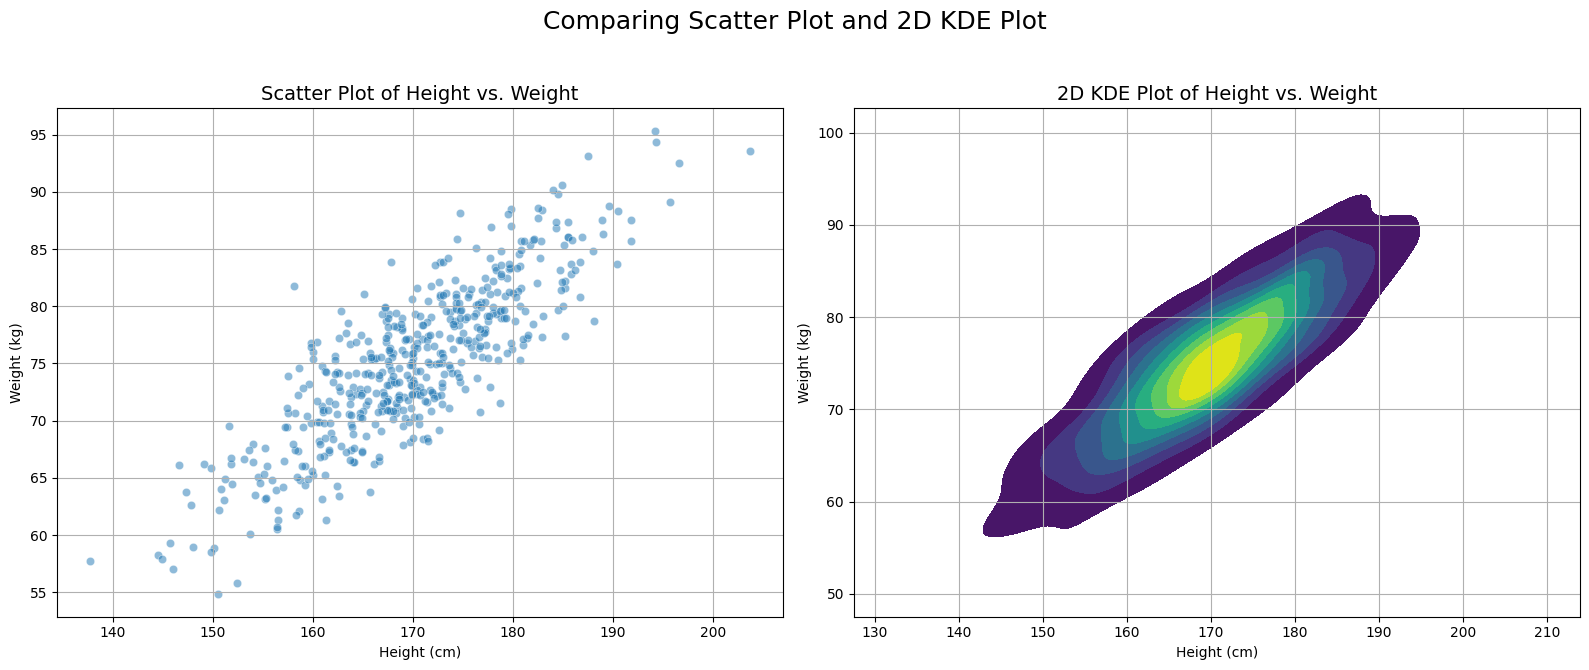

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Sample Data
np.random.seed(42) # for reproducibility

# Generate 500 data points for height and weight with a positive correlation
# We'll use a multivariate normal distribution for this
mean = [170, 75]  # Mean height (cm), Mean weight (kg)
cov = [[100, 60],  # Covariance matrix: height variance, covariance, weight variance
       [60, 50]]
data = np.random.multivariate_normal(mean, cov, 500)

df = pd.DataFrame(data, columns=['height_cm', 'weight_kg'])


# 2. Sample Code for the Plots

# Create a figure with two subplots to compare with a scatter plot
fig, axes = plt.subplots(1, 2, figsize=(16, 7))


# --- Plot 1: The Standard Scatter Plot (for comparison) ---
sns.scatterplot(data=df, x='height_cm', y='weight_kg', alpha=0.5, ax=axes[0])
axes[0].set_title('Scatter Plot of Height vs. Weight', fontsize=14)
axes[0].set_xlabel('Height (cm)')
axes[0].set_ylabel('Weight (kg)')
axes[0].grid(True)


# --- Plot 2: The 2D KDE Plot ---
# data: The DataFrame
# x, y: The two numerical columns
# fill: If True, shades the contours with a gradient.
# cmap: The color map to use for the shading.
# thresh: The lowest contour level to plot.
sns.kdeplot(
    data=df,
    x='height_cm',
    y='weight_kg',
    fill=True,
    cmap='viridis', # A common and effective color map
    thresh=0.05, # Don't plot contours for the lowest 5% of density
    ax=axes[1]
)
axes[1].set_title('2D KDE Plot of Height vs. Weight', fontsize=14)
axes[1].set_xlabel('Height (cm)')
axes[1].set_ylabel('Weight (kg)')
axes[1].grid(True)


plt.suptitle('Comparing Scatter Plot and 2D KDE Plot', fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
plt.show()

#### What Type of Information It Provides
The 2D KDE plot provides a different perspective than a simple scatter plot.

- Density and Concentration: Its primary purpose is to show where the data points are most concentrated. It answers the question, "What is the most common combination of height and weight?" The "peak" of the contour map represents the mode of the joint distribution.

- Shape of the Joint Distribution: It gives a clear picture of the overall shape of the relationship. You can see if the data is clustered in a circular pattern, an elliptical pattern (indicating correlation), or even multiple distinct clusters.

- Correlation: The orientation of the contours indicates the correlation between the two variables.

- Positive Correlation: The contours will be stretched from bottom-left to top-right (as in our example).

- Negative Correlation: The contours will be stretched from top-left to bottom-right.

- No Correlation: The contours will be roughly circular.

- Identifying Bimodal/Multimodal Distributions: If your data has two or more distinct sub-groups, the 2D KDE plot will show multiple "peaks" or separate islands of high density, which might be completely hidden in a crowded scatter plot.

#### Scenarios for Using a 2D KDE Plot
- When a Scatter Plot is Overplotted: This is the number one reason to use it. If you have thousands or millions of data points, a scatter plot will just look like a solid blob of color. The 2D KDE plot cuts through the noise and shows you the underlying density structure.

- To Identify the Mode of a Joint Distribution: When you need to find the most common combination of two variables, the peak of the 2D KDE plot is the best visual indicator.

- To Visualize Bivariate Clusters: When you suspect there are multiple sub-groups in your data based on two features, a 2D KDE plot can make these clusters visually obvious.

- As an Alternative to jointplot: Seaborn's jointplot(kind='kde') is a fantastic shortcut that combines a 2D KDE plot in the center with 1D KDE plots for each variable on the axes, giving a complete picture of the bivariate and univariate distributions in one figure.